In [ ]:
!pip install -q imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

In [ ]:
SEED = 42
np.random.seed(SEED)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

EICU_PATH   = '/content/drive/MyDrive/AI in Medicine/eicu_train/eicu_features.csv'
OUT_CLEANED = '/content/drive/MyDrive/AI in Medicine/eicu_train/eicu_cleaned.csv'
OUT_FINAL   = '/content/drive/MyDrive/AI in Medicine/eicu_train/eicu_final.csv'
SCALER_PATH = '/content/drive/MyDrive/AI in Medicine/eicu_train/scaler.pkl'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(EICU_PATH)

CATEGORICAL_COLS = ['ethnicity_grp', 'careunit', 'admit_source', 'icd9_chapter', 'dataset']
ID_COLS          = ['stay_id']
TARGET_COL       = 'mortality'

numeric_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in ID_COLS + [TARGET_COL]]

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Numeric cols  : {len(numeric_cols)}")
print(f"Mortality rate: {df[TARGET_COL].mean():.3f}")
df.head()

Shape         : 2,520 rows × 73 cols
Numeric cols  : 66
Mortality rate: 0.050


,stay_id,age_clean,gender_binary,ethnicity_grp,icu_los_days,careunit,admit_source,mortality,albumin_max,alt_max,...,ssystolic_max,ssystolic_mean,sdiastolic_min,sdiastolic_max,sdiastolic_mean,systemicmean_min,systemicmean_max,systemicmean_mean,icd9_chapter,dataset
0,141764,87.0,0.0,White,0.238889,MICU,Unknown,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicu
1,141765,87.0,0.0,White,1.562500,MICU,Unknown,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicu
2,143870,76.0,1.0,White,0.550694,SICU,Operating Room,0,NaN,NaN,...,138.0,109.816456,36.0,57.0,42.71519,47.0,79.0,60.835443,Unknown,eicu
3,144815,34.0,0.0,White,0.778472,MICU,Emergency,0,3.6,42.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicu
4,145427,61.0,1.0,White,0.950694,SICU,Emergency,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Infectious & parasitic,eicu


**HANDLING MISSING VALUES - DROPPING ROWS AND COLUMNS**

In [ ]:
missing_pct = df.isnull().mean() * 100

cols_to_drop = missing_pct[missing_pct > 30].index.tolist() #drop column if 30% (or more) of data is missing

print(f"Columns to drop: {len(cols_to_drop)}")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

numeric_cols = [c for c in numeric_cols if c not in cols_to_drop] #drop the numeric column if 30% (or more) of data is missing

Columns to drop: 25
['albumin_max', 'alt_max', 'inr_max', 'lactate_max', 'albumin_mean', 'alt_mean', 'inr_mean', 'lactate_mean', 'albumin_min', 'alt_min', 'inr_min', 'lactate_min', 'temp_min', 'temp_max', 'temp_mean', 'ssystolic_min', 'ssystolic_max', 'ssystolic_mean', 'sdiastolic_min', 'sdiastolic_max', 'sdiastolic_mean', 'systemicmean_min', 'systemicmean_max', 'systemicmean_mean', 'icd9_chapter']


In [ ]:
missing_per_patient = df[numeric_cols].isnull().mean(axis=1) * 100
rows_to_drop = missing_per_patient[missing_per_patient > 10].index #drop row if 10% (or more) of data is missing

print(f"Rows to drop (>10% missing): {len(rows_to_drop)}")

df.drop(index=rows_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

Rows to drop (>10% missing): 724


**HANDLING MISSING VALUES - IMPUTATION ACCORDING TO survived/died GROUPS USING RANDOM VALUES FROM EACH GROUP'S IQR**

In [ ]:
missing_pct2   = df[numeric_cols].isnull().mean() * 100
cols_to_impute = missing_pct2[missing_pct2 > 0].index.tolist() # columns with NaN

for col in cols_to_impute:
    for cls in [0, 1]: # impute separately for each class (survived / died)
        mask = (df[TARGET_COL] == cls) & (df[col].isna())
        vals = df.loc[df[TARGET_COL] == cls, col].dropna()
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75) # IQ range
        df.loc[mask, col] = np.random.uniform(q1, q3, size=mask.sum()) # fill with random value in [Q1, Q3]

print(f"Remaining NaN: {df[numeric_cols].isnull().sum().sum()}")

Remaining NaN: 0


**HANDLING OUTLIERS - IQR METHOD**

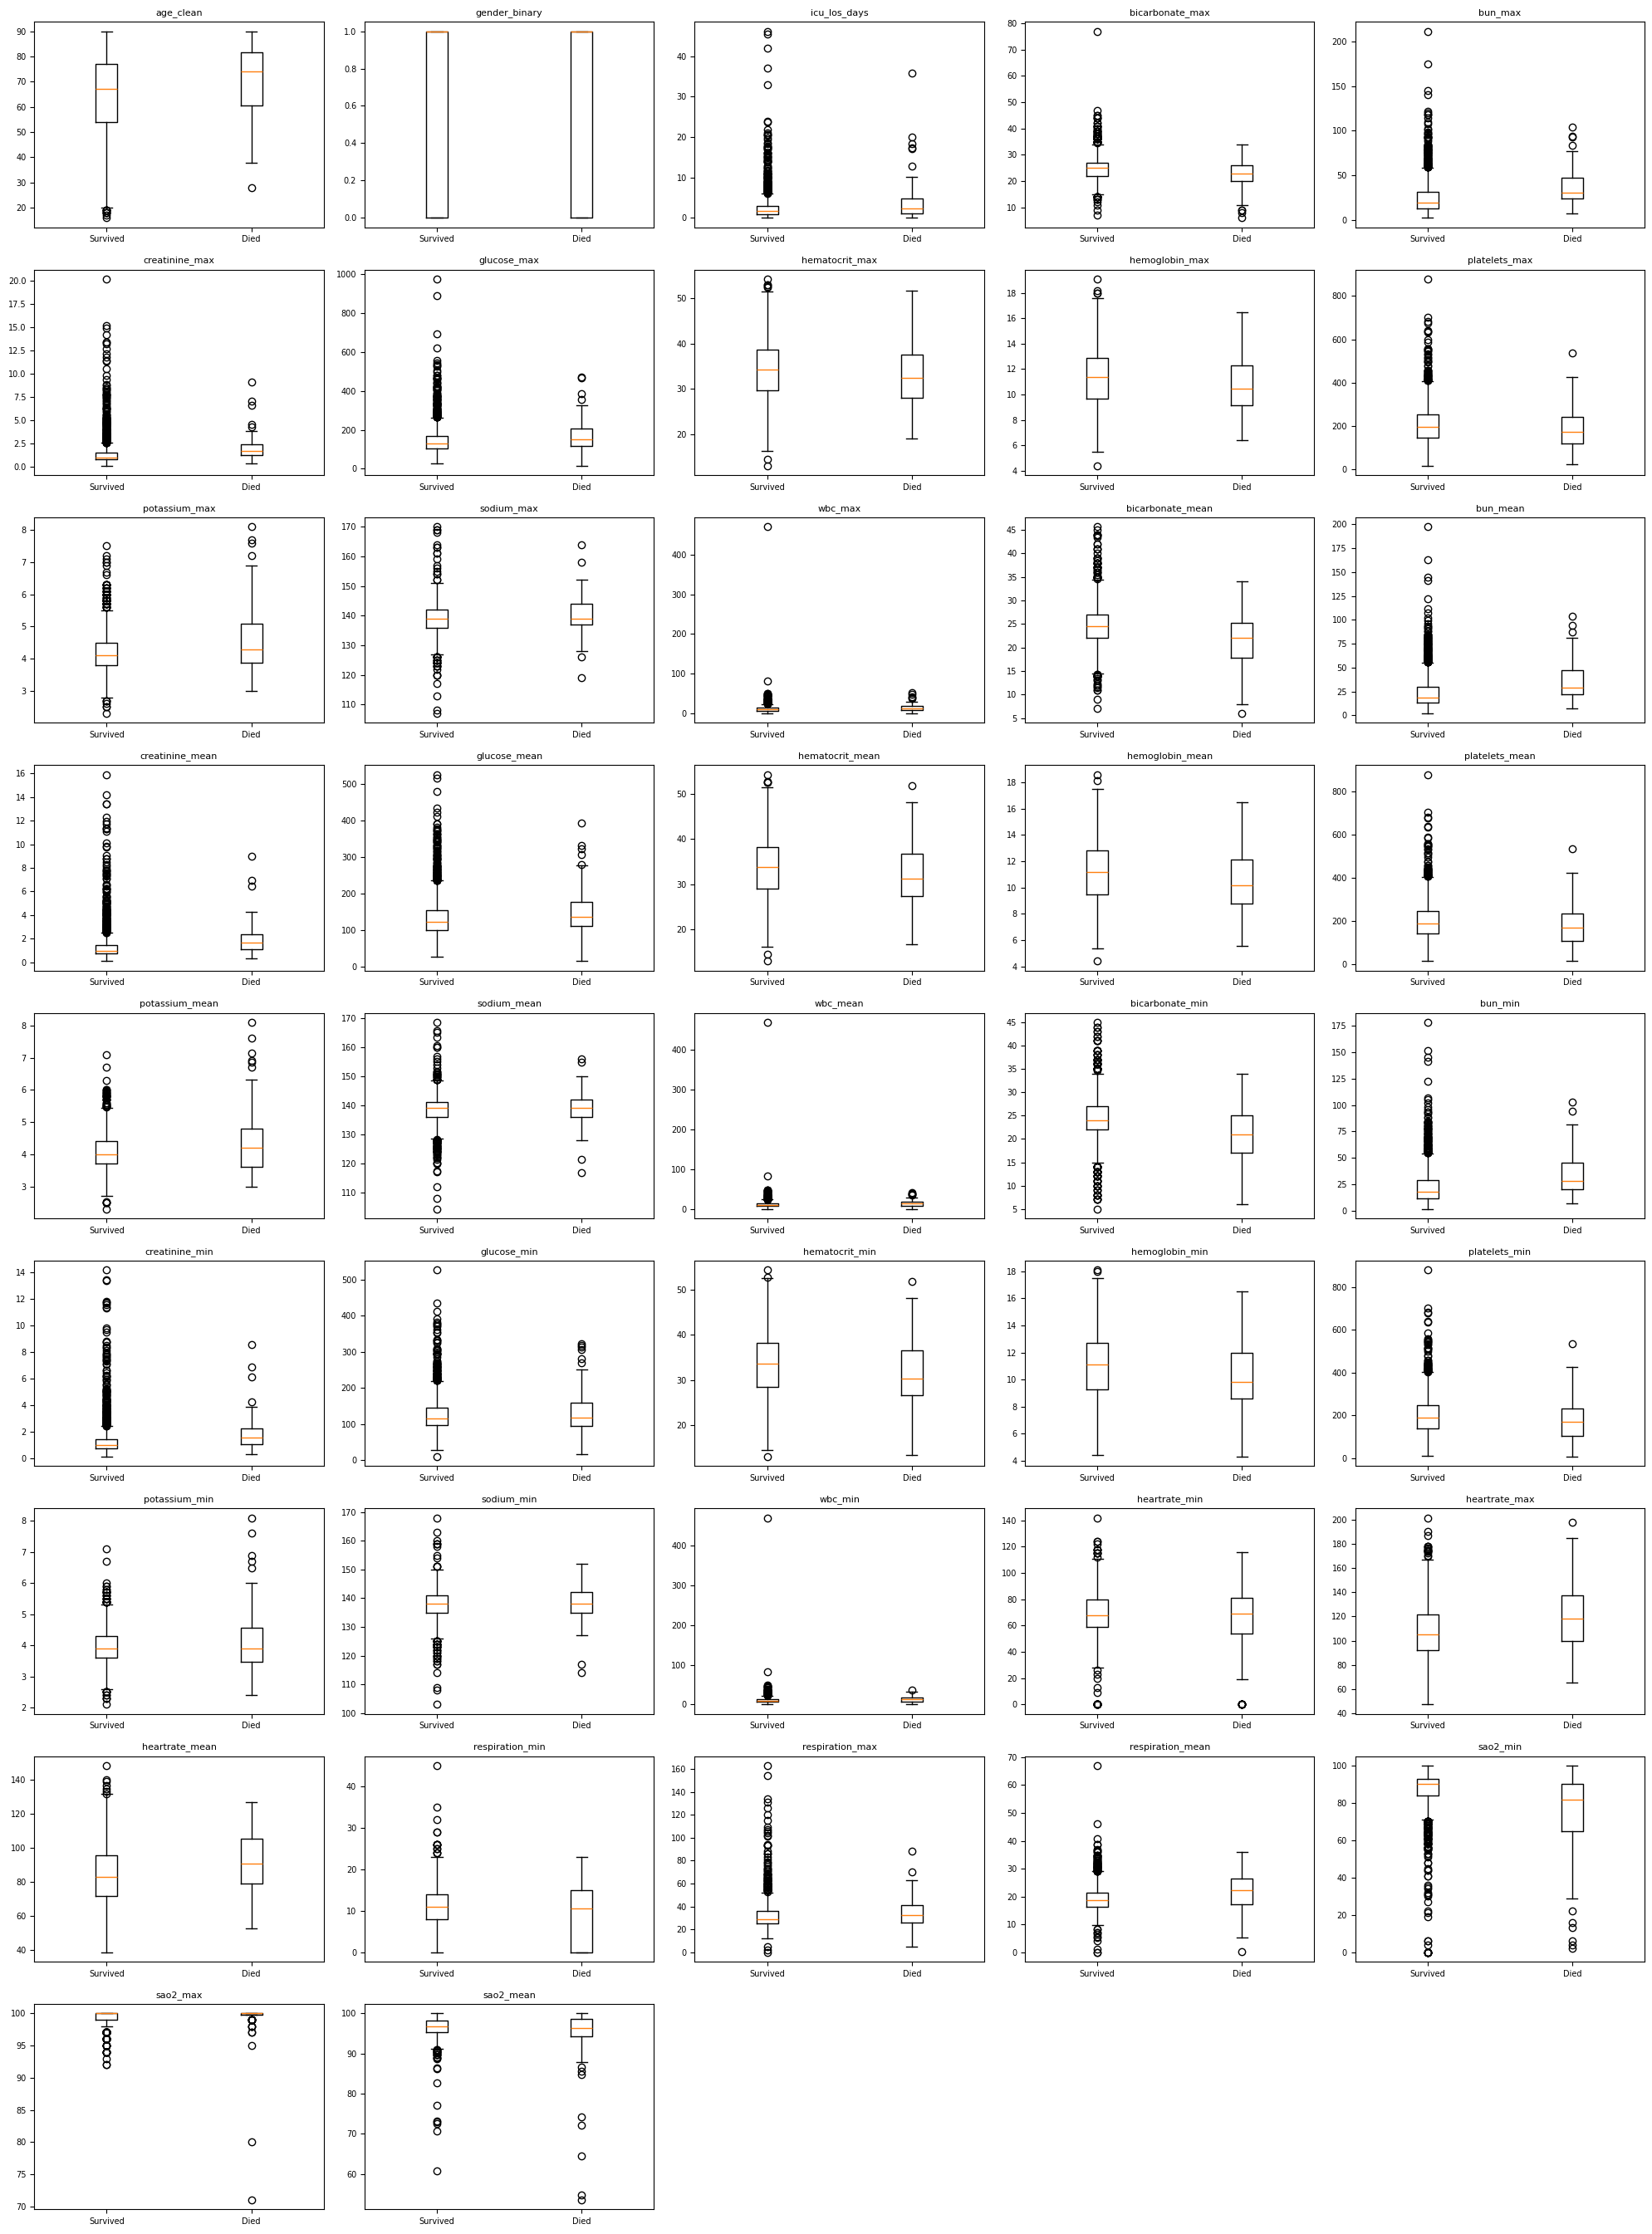

In [ ]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 4) // 5

fig, axes = plt.subplots(n_rows, 5, figsize=(20, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot([df[df[TARGET_COL]==0][col].dropna(),
                     df[df[TARGET_COL]==1][col].dropna()],
                    labels=['Survived', 'Died'])
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr) #removing outliers with IQR method

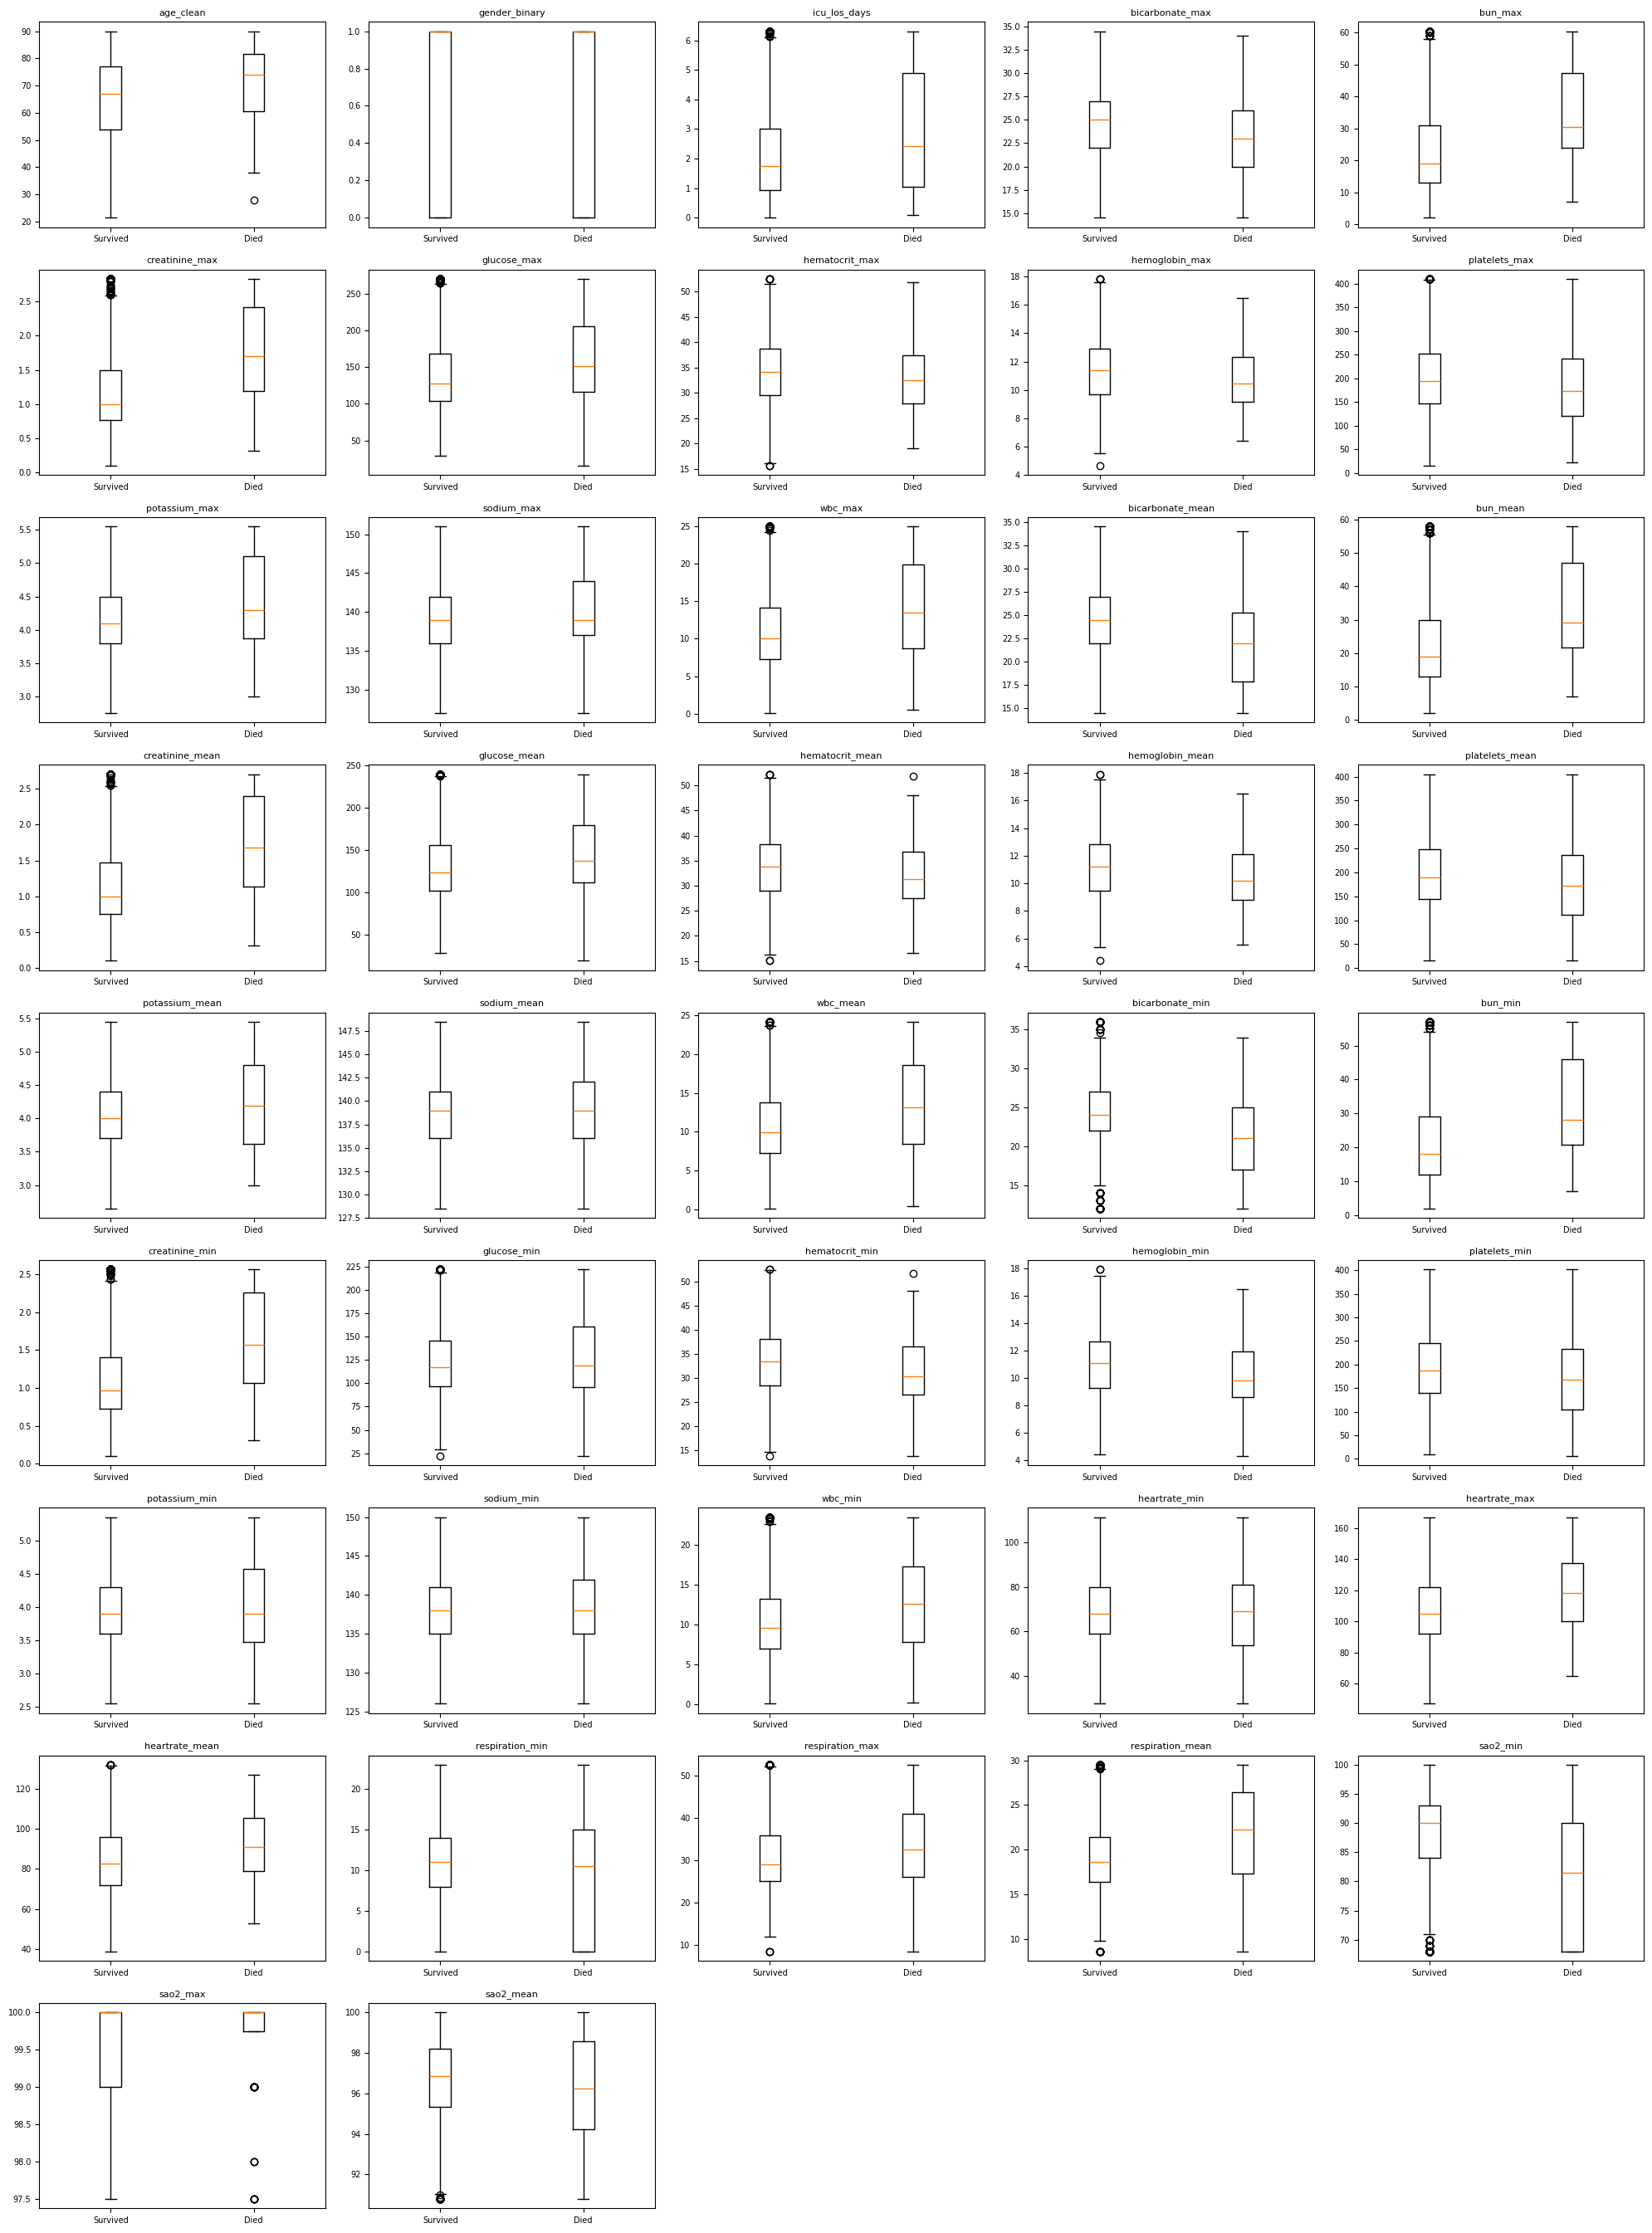

In [ ]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 4) // 5

fig, axes = plt.subplots(n_rows, 5, figsize=(20, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot([df[df[TARGET_COL]==0][col].dropna(),
                     df[df[TARGET_COL]==1][col].dropna()],
                    labels=['Survived', 'Died'])
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**SCALING - StandardScaler**

In [ ]:
numeric_cols_to_scale = [c for c in numeric_cols if c != 'gender_binary']

scaler = StandardScaler()
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

joblib.dump(scaler, SCALER_PATH)

['/content/drive/MyDrive/AI in Medicine/eicu_train/scaler.pkl']

In [ ]:
drop_cols = ID_COLS + [TARGET_COL] + [c for c in CATEGORICAL_COLS if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[TARGET_COL]

**FEATURE SELECTION - Mann-Whitney U**

In [ ]:
results = []
for col in X.columns:
    _, p = stats.mannwhitneyu(X[y==0][col], X[y==1][col], alternative='two-sided')
    results.append({'feature': col, 'p_value': p})

results_df = pd.DataFrame(results).sort_values('p_value')
print(results_df.to_string(index=False))

         feature      p_value
         bun_max 2.579225e-12
        bun_mean 1.567870e-11
  creatinine_max 2.819392e-11
 creatinine_mean 1.223229e-10
         bun_min 1.476170e-10
        sao2_min 6.738073e-10
  creatinine_min 1.438974e-09
 bicarbonate_min 2.632895e-07
bicarbonate_mean 7.812467e-07
respiration_mean 8.328039e-07
   heartrate_max 1.841083e-05
  heartrate_mean 1.893766e-05
 bicarbonate_max 3.711019e-05
         wbc_max 2.687626e-04
        wbc_mean 4.581215e-04
       age_clean 6.932128e-04
         wbc_min 1.256819e-03
   platelets_min 1.781771e-03
     glucose_max 2.043643e-03
   potassium_max 2.577694e-03
  hemoglobin_min 3.328049e-03
  platelets_mean 4.434147e-03
    icu_los_days 5.716644e-03
 respiration_max 6.653636e-03
  hematocrit_min 8.374369e-03
 hemoglobin_mean 9.671233e-03
   platelets_max 1.367156e-02
 hematocrit_mean 1.744419e-02
  hemoglobin_max 2.849253e-02
    glucose_mean 3.013255e-02
  potassium_mean 3.829570e-02
  hematocrit_max 4.875522e-02
       sao

In [ ]:
for threshold, label in [(0.05, 'p<0.05'), (0.10, 'p<0.10'), (1.01, 'all features')]:  # try 3 different p-value thresholds
    sig = results_df[results_df['p_value'] < threshold]['feature'].tolist() # select features below threshold
    sc  = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X[sig], y, cv=5, scoring='roc_auc'
    )
    print(f"{label:15s} ({len(sig):2d} features) — AUROC: {sc.mean():.3f} ± {sc.std():.3f}")

p<0.05          (33 features) — AUROC: 0.792 ± 0.034
p<0.10          (34 features) — AUROC: 0.794 ± 0.035
all features    (42 features) — AUROC: 0.809 ± 0.038


In [ ]:
X_final = X.copy() #all features are selected since AUROC of all features > AUROC of Mann-Whitney U results

**HANDLING CLASS UNBALANCE - SMOTE VS class_weight = "balanced"**

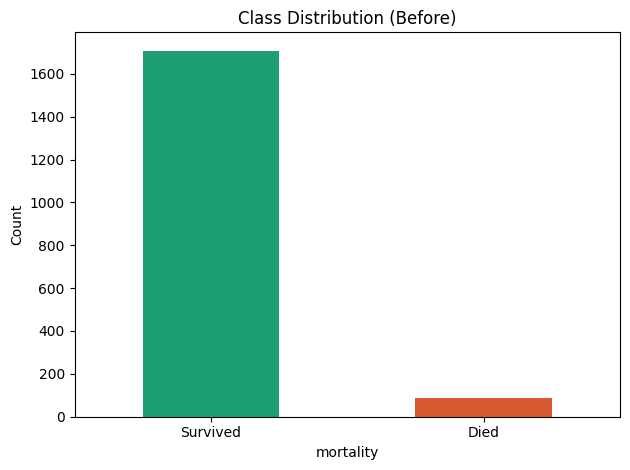

In [ ]:
y.value_counts().plot(kind='bar', color=['#1D9E75', '#D85A30'])
plt.xticks([0, 1], ['Survived', 'Died'], rotation=0)
plt.title('Class Distribution (Before)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
scores_no = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_final, y, cv=5, scoring='roc_auc'
)
scores_cw = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    X_final, y, cv=5, scoring='roc_auc'
)

sm = SMOTE(random_state=SEED)
X_final_sm, y_final_sm = sm.fit_resample(X_final, y)
scores_smote = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_final_sm, y_final_sm, cv=5, scoring='roc_auc'
)

print(f"No handling  — AUROC: {scores_no.mean():.3f} ± {scores_no.std():.3f}")
print(f"class_weight — AUROC: {scores_cw.mean():.3f} ± {scores_cw.std():.3f}")
print(f"SMOTE        — AUROC: {scores_smote.mean():.3f} ± {scores_smote.std():.3f}") #huge difference when SMOTE is used

No handling  — AUROC: 0.809 ± 0.038
class_weight — AUROC: 0.799 ± 0.052
SMOTE        — AUROC: 0.884 ± 0.016


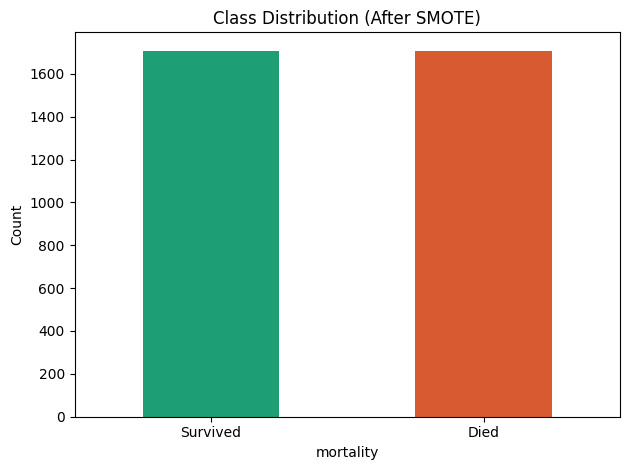

In [ ]:
y_final_sm.value_counts().plot(kind='bar', color=['#1D9E75', '#D85A30'])
plt.xticks([0, 1], ['Survived', 'Died'], rotation=0)
plt.title('Class Distribution (After SMOTE)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
df_final = pd.concat([X_final_sm, y_final_sm], axis=1)
df_final.to_csv(OUT_FINAL, index=False)